In [1]:
from numba import njit, prange
import numpy as np
import faiss

data = np.load("/home/dhem/workspace/2024.3/data/save/train_test-0-0-0-0.npz")

AU2KCALMOL = 627.509

x = data["x"]
y = data["y"]
w = data["w"]
coor = data["coor"]
name = data["name"]

In [2]:
(num_sample, dim_sample) = x.shape
res = faiss.StandardGpuResources()
flat_config = faiss.GpuIndexFlatConfig()
flat_config.device = 0
index = faiss.GpuIndexFlatL2(res, dim_sample, flat_config)
index.add(x)

In [3]:
b = x.copy()
min_number = 40
distances, indices = index.search(b, min_number)

var_y = np.var(np.einsum("ij,i->ij", y[indices], x[:, 0] * w), axis=1)
argsort_ = np.argsort(var_y)[::-1][:100]
print(np.einsum("ij,i->ij", y[indices], x[:, 0] * w)[argsort_])

[[-4.73994617e-05 -4.79877250e-05 -4.73927406e-05 -4.45448024e-05
  -4.45735080e-05 -4.67054803e-05 -4.56267719e-05 -4.16096525e-05
  -3.35190768e-05 -3.31722212e-05 -2.98717720e-05 -2.49402721e-05
  -2.42643075e-05 -3.98025163e-05 -2.82803005e-05 -2.44519279e-05
  -4.41069759e-05 -4.84284252e-05 -3.39282014e-05 -2.42730456e-05
  -3.91499579e-05 -3.99661444e-05 -5.10057070e-05 -3.30811642e-05
  -5.42751939e-06 -4.36324458e-05 -5.20924054e-06 -4.58227533e-05
  -3.10102296e-05 -2.41602779e-05 -2.45849827e-05 -7.58285836e-06
  -7.37800324e-06 -4.31193865e-06 -4.12936163e-06 -4.79674947e-05
  -4.95478565e-05 -3.92065099e-05 -2.41969374e-05 -3.79003639e-05]
 [-3.98547454e-05 -3.97171113e-05 -3.18371344e-05 -3.15820074e-05
  -3.96698706e-05 -3.80944748e-05 -4.02858320e-05 -4.23926696e-05
  -4.07865891e-05 -4.11287937e-05 -2.32616754e-05 -2.31590957e-05
  -4.24628725e-05 -4.13210107e-05 -4.21187019e-05 -2.21457396e-05
  -4.24835339e-05 -3.83793813e-05 -3.75894916e-05 -4.08790307e-05
  -2.2331

In [4]:
x.shape

(114339, 108)

In [5]:
distance = x[indices[argsort_], 0]
energy = np.einsum("ij,i->ij", y[indices[argsort_]], (x[:, 0] * w)[argsort_])
print(distance)

[[0.08692904 0.08295334 0.08545292 0.08623184 0.08320347 0.08423305
  0.07995235 0.08197637 0.08053622 0.07312881 0.08057561 0.08450741
  0.07984096 0.08050845 0.08678982 0.07546589 0.08024566 0.07460158
  0.08713362 0.07243133 0.07386602 0.07457902 0.06882883 0.06522783
  0.06634117 0.07228361 0.06623144 0.08352984 0.08552766 0.0707675
  0.07806228 0.07000479 0.0699048  0.0651885  0.06499176 0.06942794
  0.06903594 0.07616478 0.07131747 0.08332268]
 [0.0986809  0.09394369 0.09040985 0.09342516 0.09571316 0.07868167
  0.09095535 0.09053378 0.09539703 0.09620954 0.09663272 0.09679144
  0.08924389 0.09695445 0.09172224 0.07984068 0.09206756 0.09726045
  0.09683497 0.09366538 0.08672327 0.08651686 0.08606558 0.08664334
  0.0912801  0.08200254 0.08062581 0.08384387 0.08363963 0.08191057
  0.08806236 0.0878351  0.08874582 0.08992649 0.08838937 0.08399038
  0.09438554 0.09026419 0.08621447 0.09027248]
 [0.09438554 0.09539703 0.09695445 0.08606558 0.09620954 0.0912801
  0.08747844 0.09053378 

In [6]:
from matplotlib import pyplot as plt

color_dict = {
    "methane_cc-pVDZ_0-1_1_-0.2000": "#004D40",
    "methane_cc-pVDZ_0-1_1_-0.1000": "#1A237E",
    "methane_cc-pVDZ_0-1_1_0.0000": "#7B1FA2",
    "methane_cc-pVDZ_0-1_1_0.1000": "#B71C1C",
    "methane_cc-pVDZ_0-1_1_0.2000": "#FF6F00",
}

plt.rcParams["figure.figsize"] = np.array([3, 3]) * 520 / 72

f, axes = plt.subplots(10, 10)
axes = axes.reshape(10, 10)

begin_y = 0.025
end_y = 0.95
int_y = 0.0
begin_x = 0.025
end_x = 0.95
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )
        if i != 0:
            axes[i][j].set_xticks([])
        if j != 0:
            axes[i][j].set_yticks([])


for i in range(argsort_.shape[0]):
    axes_i, axes_j = np.unravel_index(i, (10, 10))
    for j in range(indices.shape[1]):
        axes[axes_i, axes_j].scatter(
            distance[i][j],
            np.abs(energy[i][j] - energy[i][0]) * 627.509,
            c=color_dict[name[indices[argsort_[i]]][j]],
        )
        axes[axes_i, axes_j].set_xlim(0.03, 0.12)
        axes[axes_i, axes_j].set_ylim(-0.003, 0.033)
plt.savefig("test-distance.pdf", dpi=300)
plt.clf()

<Figure size 2166.67x2166.67 with 0 Axes>

In [4]:
# @njit(parallel=True)
def get_min_distance(x, y, w, coor, name):
    """
    obtain the minimum distance between the points
    only for the largest y
    """
    max_num_local = 20
    x_return = np.zeros((10, max_num_local, x.shape[1]), dtype=np.float64)
    y_return = np.zeros((10, max_num_local), dtype=np.float64)
    w_return = np.zeros((10, max_num_local), dtype=np.float64)
    corr_return = np.zeros(
        (10, max_num_local, coor.shape[1], coor.shape[2]), dtype=np.float64
    )
    name_return = np.zeros((10, max_num_local), dtype=name.dtype)
    distance_return = np.zeros((10, max_num_local), dtype=np.float64)

    for j in prange(10):
        distance = np.zeros(x.shape[0], dtype=np.float64)
        for i in range(x.shape[0]):
            distance[i] = np.sqrt(np.sum((x[i] - x[j]) ** 2))
        argsort_ = np.argsort(distance)[:max_num_local]
        distance_return[j] = distance[argsort_]
        x_return[j] = x[argsort_]
        y_return[j] = y[argsort_]
        w_return[j] = w[argsort_]
        corr_return[j] = coor[argsort_]
        name_return[j] = name[argsort_]
        print(y_return[j] * w_return[j, 0] * x_return[j, 0, 0] * AU2KCALMOL)
        print(name_return[j])
    return x_return, y_return, w_return, distance_return, corr_return, name_return

In [5]:
from matplotlib import pyplot as plt

x_show = x[argsort_]
y_show = y[argsort_]
w_show = w[argsort_]
coor_show = coor[argsort_]
name_show = name[argsort_]

x_return, y_return, w_return, distance_return, corr_return, name_return = (
    get_min_distance(x_show, y_show, w_show, coor_show, name_show)
)

[-0.01471795 -0.01465576 -0.01531681 -0.01414886 -0.01243377 -0.01510957
 -0.01252685 -0.01434769 -0.01345881 -0.01348277 -0.01201353 -0.01452534
 -0.01158832 -0.01244433 -0.01300001 -0.0131566  -0.01654011 -0.0115608
 -0.00904107 -0.01560696]
['methane_cc-pVDZ_0-1_1_-0.2000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_-0.2000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_-0.1000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_-0.2000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_0.2000' 'methane_cc-pVDZ_0-1_1_0.1000'
 'methane_cc-pVDZ_0-1_1_-0.1000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_0.0000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_0.0000' 'methane_cc-pVDZ_0-1_1_0.0000'
 'methane_cc-pVDZ_0-1_1_0.1000' 'methane_cc-pVDZ_0-1_1_0.0000'
 'methane_cc-pVDZ_0-1_1_0.0000' 'methane_cc-pVDZ_0-1_1_0.0000']
[-0.01408758 -0.01237885 -0.01240832 -0.0139199  -0.0096437  -0.01676774
 -0.00968083 -0.01286362 -0.01536295 -0.0

8
distance [0.         0.18294522 0.20969797 0.22427748 0.26938073 0.3092688
 0.39595935 0.41095422 0.44603147 0.44805381 0.48427874 0.48697376
 0.49180209 0.59093175 0.60010404 0.62629091 0.67501265 0.69277231
 0.73536311 0.73680873]
['methane_cc-pVDZ_0-1_1_-0.1000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_-0.2000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_-0.1000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_-0.2000' 'methane_cc-pVDZ_0-1_1_0.2000'
 'methane_cc-pVDZ_0-1_1_0.0000' 'methane_cc-pVDZ_0-1_1_0.0000'
 'methane_cc-pVDZ_0-1_1_-0.2000' 'methane_cc-pVDZ_0-1_1_0.0000'
 'methane_cc-pVDZ_0-1_1_0.0000' 'methane_cc-pVDZ_0-1_1_0.0000'
 'methane_cc-pVDZ_0-1_1_-0.2000' 'methane_cc-pVDZ_0-1_1_-0.2000'
 'methane_cc-pVDZ_0-1_1_0.0000' 'methane_cc-pVDZ_0-1_1_0.0000'
 'methane_cc-pVDZ_0-1_1_-0.2000' 'methane_cc-pVDZ_0-1_1_-0.1000']
energy density [-0.01475579 -0.01528493 -0.01543521 -0.01538628 -0.0150521  -0.01762275
 -0.01737853 -0.01923417 -0.017131

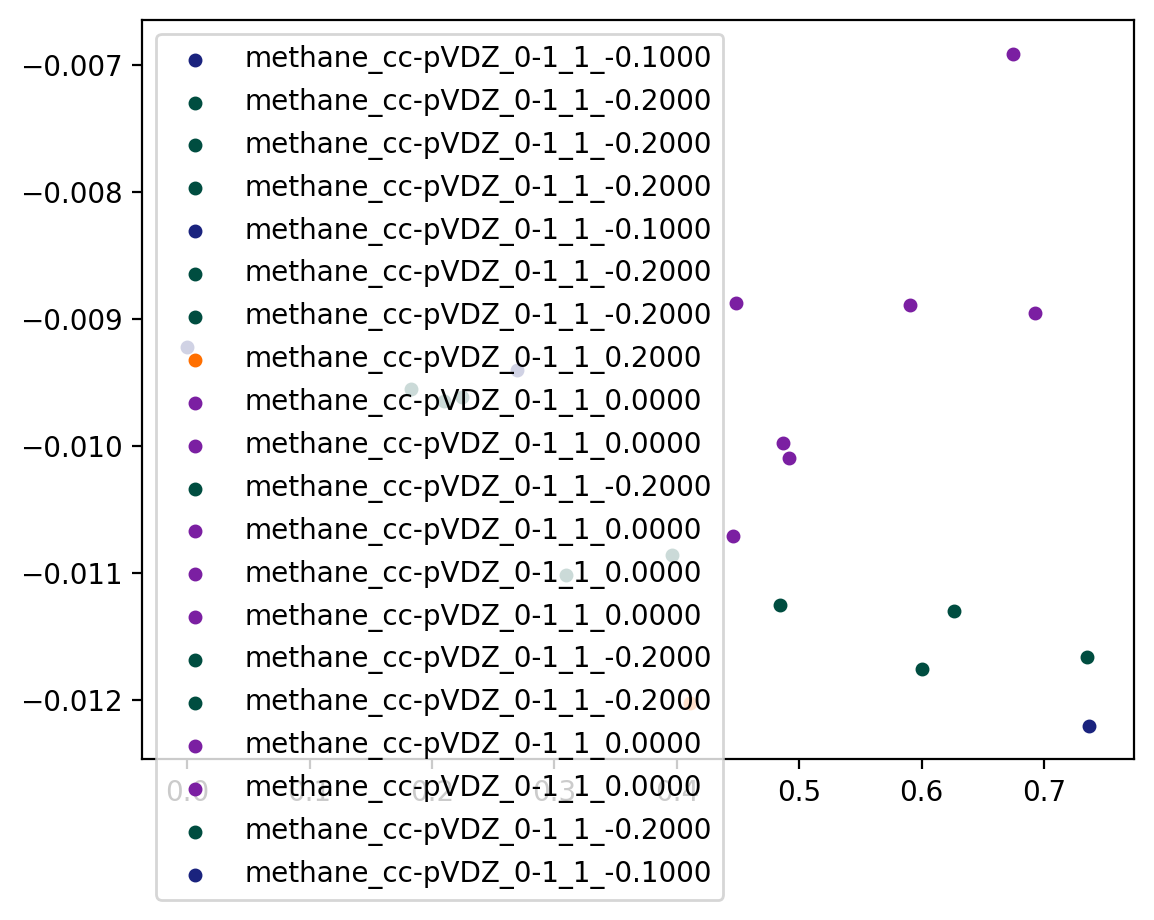

energy [-1.46900977e-05 -1.52168808e-05 -1.53664946e-05 -1.53177828e-05
 -1.49850960e-05 -1.75442975e-05 -1.73011617e-05 -1.91485474e-05
 -1.70556070e-05 -1.41364987e-05 -1.79210037e-05 -1.58963596e-05
 -1.60878393e-05 -1.41701477e-05 -1.87293329e-05 -1.79970420e-05
 -1.10129831e-05 -1.42590239e-05 -1.85794988e-05 -1.94380208e-05]


<Figure size 640x480 with 0 Axes>

In [6]:
index_check = 8
print(index_check)
print("distance", distance_return[index_check, :])
print(name_return[index_check, :])
print("energy density", y_return[index_check, :])

color_dict = {
    "methane_cc-pVDZ_0-1_1_-0.2000": "#004D40",
    "methane_cc-pVDZ_0-1_1_-0.1000": "#1A237E",
    "methane_cc-pVDZ_0-1_1_0.0000": "#7B1FA2",
    "methane_cc-pVDZ_0-1_1_0.1000": "#B71C1C",
    "methane_cc-pVDZ_0-1_1_0.2000": "#FF6F00",
}

for j in range(np.shape(distance_return)[1]):
    plt.scatter(
        distance_return[index_check, j],
        y_return[index_check, j]
        * w_return[index_check, 0]
        * x_return[index_check, 0, 0]
        * AU2KCALMOL,
        s=16,
        c=color_dict[name_return[index_check, j]],
        label=name_return[index_check, j],
    )
plt.legend()
plt.show()
plt.clf()

print(
    "energy",
    y_return[index_check, :] * w_return[index_check, 0] * x_return[index_check, 0, 0],
)
# plt.savefig("min_distance.png", dpi=300, bbox_inches="tight")
# plt.savefig("min_distance.pdf", dpi=300, bbox_inches="tight")